# Mosna Analysis

## preprocessing without normalization

In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning, FitFailedWarning
warnings.simplefilter('ignore', FitFailedWarning)
warnings.simplefilter('ignore', ConvergenceWarning)
warnings.simplefilter('ignore', FutureWarning)
warnings.simplefilter('ignore', DeprecationWarning)
warnings.simplefilter('ignore', UserWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from time import time
import warnings
import joblib
from pathlib import Path
from time import time
from tqdm import tqdm
import copy
import matplotlib as mpl
import napari
import colorcet as cc
import composition_stats as cs
from sklearn.impute import KNNImputer
from lifelines import KaplanMeierFitter, CoxPHFitter

from tysserand import tysserand as ty
from mosna import mosna

import matplotlib as mpl
mpl.rcParams["figure.facecolor"] = 'white'
mpl.rcParams["axes.facecolor"] = 'white'
mpl.rcParams["savefig.facecolor"] = 'white'

In [19]:
import glob
import re

objects_path = glob.glob("data/processed/Bram_IMC/acquired_csv_files/*.csv")
files=dict()



sample_number=1
for file in objects_path:
    name_file = str(Path(file).name)
    name_file = re.split(r'[_.-]', name_file)
    name_file = name_file = [str(x) for x in name_file[1:3]]
    if Path(file).with_suffix('.parquet').exists():
        obj = pd.read_parquet(Path(file).with_suffix('.parquet'))
        obj.drop(columns='Unnamed: 0', inplace=True)
        obj['patient'] = name_file[0]
        obj['sample'] = name_file[1]
        files.setdefault(f'sample {sample_number}', obj)
    else:
        obj = pd.read_csv(Path(file))
        obj.to_parquet(Path(file).with_suffix('.parquet'))
        obj.drop(columns='Unnamed: 0', inplace=True)
        obj['patient'] = name_file[0]
        obj['sample'] = name_file[1]
        files.setdefault(f'sample {sample_number}', obj)
    
    sample_number+=1
        
    

In [20]:
verif = files["sample 1"].columns
concatanable = True

for file in files.values():
    
    if file.columns.all() != verif.all():
        print("not concatanable files")
        concatanable = False

nb_row=0
nb_row_concat=0
if concatanable:
    concat_obj=pd.DataFrame()
    for file in files.values():
        nb_row+=file.shape[0]
        concat_obj = pd.concat([concat_obj, file], ignore_index=True)
    nb_row_concat=concat_obj.shape[0]

if nb_row == nb_row_concat:
    print(f"Concaténation réussite, nombre de row : {nb_row_concat}")



Concaténation réussite, nombre de row : 401568


In [22]:
### sample n° --> cell-ID 
cell_ID = pd.Series([i for i in range(len(concat_obj))], name='cell_ID')
sample_cell = pd.concat([cell_ID,concat_obj[['patient','sample']]],axis=1)
sample_cell

,cell_ID,patient,sample
0,0,16,01
1,1,16,01
2,2,16,01
3,3,16,01
4,4,16,01
...,...,...,...
401563,401563,09,03
401564,401564,09,03
401565,401565,09,03
401566,401566,09,03


In [23]:
cell_pos=pd.concat([sample_cell['cell_ID'],concat_obj[['X_position','Y_position']]],axis=1)
concat_obj.drop(columns=['X_position','Y_position','patient','sample'], inplace=True)
cell_pos

,cell_ID,X_position,Y_position
0,0,18.241379,4.396552
1,1,26.440000,2.880000
2,2,34.518520,2.962963
3,3,76.842100,1.789474
4,4,93.074070,3.203704
...,...,...,...
401563,401563,2419.544000,1459.491200
401564,401564,2503.869600,1460.275400
401565,401565,2567.476000,1460.809600
401566,401566,2583.015400,1459.384600


In [ ]:
concat_obj

In [7]:
del files, verif, nb_row, nb_row_concat, sample_number, concatanable, cell_ID, file, name_file, obj, objects_path

## Tysserand Networks 

In [68]:
print(sample_cell[['patient','sample']].drop_duplicates().sort_values(by='patient', ascending=True))

       patient sample
301697      04     02
60290       04     03
258601      04     01
379771      09     03
74751       09     01
117984      09     02
322206      11     01
133038      11     03
173205      11     02
189624      11     04
269467      16     02
0           16     01
225815      16     03
297495       3     02
43807        3     01
205507       3  02bis
362157      33     03
33617       33     01
343597      33     02


In [69]:
patient = '3'  # @param {type:"string"}
sample = '01'    # @param {type:"string"}

filtre = (sample_cell['patient'] == patient) & (sample_cell['sample'] == sample)
print(f"Nombre de cells présente dans le sample {sample} : {filtre.sum()}")
cells = sample_cell.loc[filtre, 'cell_ID']

Nombre de cells présente dans le sample 01 : 16483


processing sample 01
there are 30/16483 nodes with < 3 edges


Text(0.5, 1.0, 'patient 3 for sample 01')

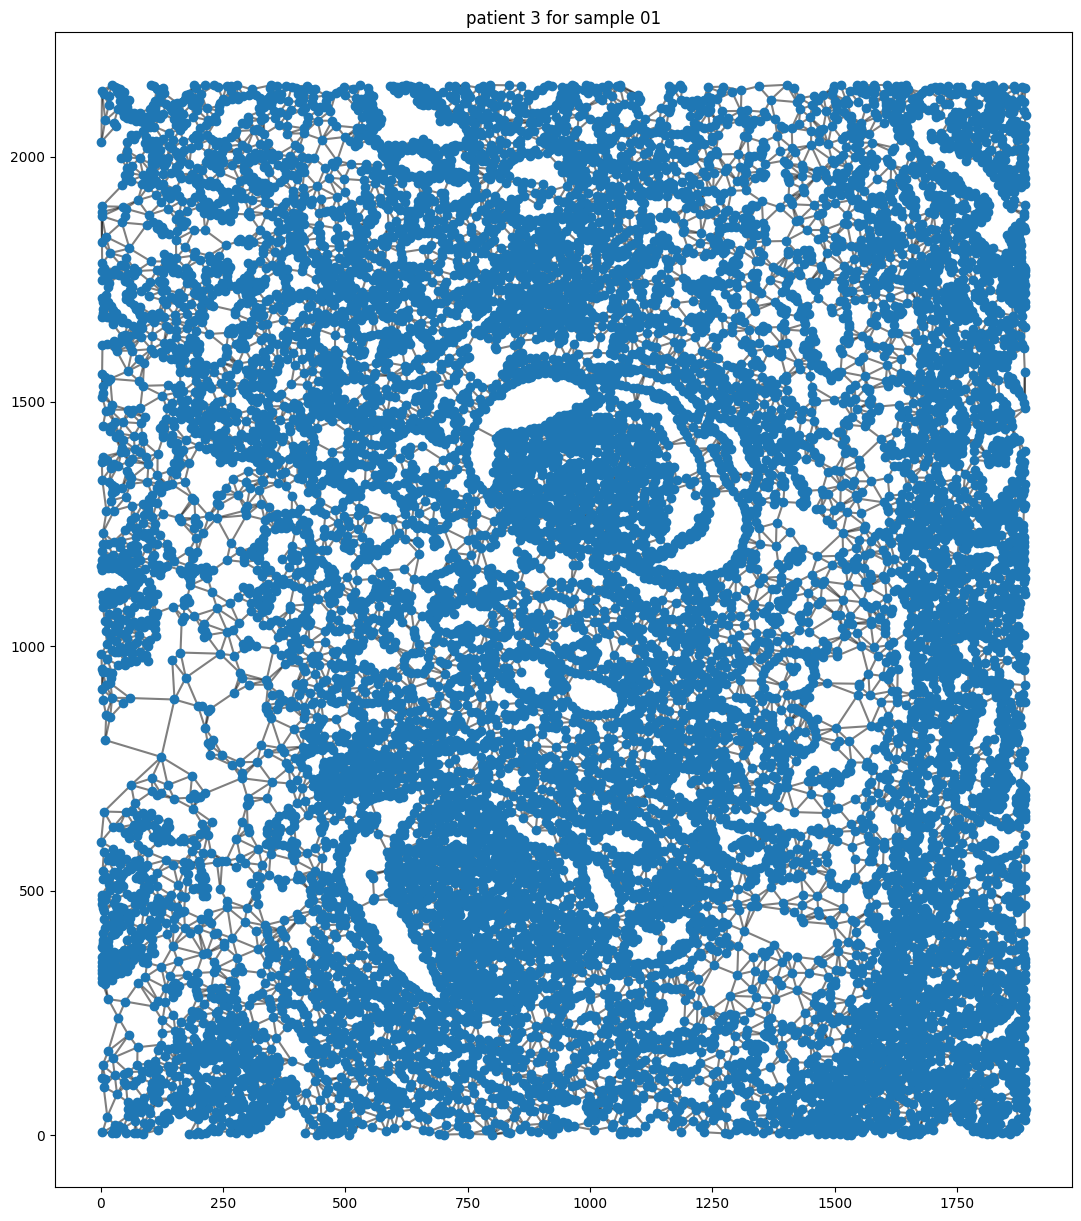

In [ ]:
filtre = cell_pos['cell_ID'].isin(cells)
coords = cell_pos.loc[filtre, ['X_position','Y_position']]

print(f"processing patient n°{patient} for sample n°{sample}")
coords = np.array(coords.values.tolist())
pairs = ty.build_delaunay(coords)
    # we want to avoid isolated cells, so we link them to their 3 closest neighbors
pairs = ty.link_solitaries(coords, pairs, method='delaunay', min_neighbors=3)

fig, ax = ty.plot_network(
    coords, pairs, 
    legend_opt={'loc': 'center left', 'bbox_to_anchor': (1.05, 0.5)},
    )
plt.title(f"Draw a Tysserand network for patient {patient} and sample {sample}")